# Explore here

Se han recopilado datos socio demográficos y de recursos de salud por condado en los Estados Unidos y queremos descubrir si existe alguna relación entre los recursos sanitarios y los datos socio demográficos.

In [2]:
# Your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df= pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv')
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [4]:
df.shape

(3140, 108)

In [5]:
pd.isnull(df).sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


In [7]:
df.dtypes

fips                        int64
TOT_POP                     int64
0-9                         int64
0-9 y/o % of total pop    float64
19-Oct                      int64
                           ...   
CKD_prevalence            float64
CKD_Lower 95% CI          float64
CKD_Upper 95% CI          float64
CKD_number                  int64
Urban_rural_code            int64
Length: 108, dtype: object

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [10]:
df.columns

Index(['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct',
       '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop',
       '30-39', '30-39 y/o % of total pop',
       ...
       'COPD_number', 'diabetes_prevalence', 'diabetes_Lower 95% CI',
       'diabetes_Upper 95% CI', 'diabetes_number', 'CKD_prevalence',
       'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
       'Urban_rural_code'],
      dtype='str', length=108)

In [11]:
# Ver solo las columnas que tiene el df real
print(df.columns.tolist())

['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct', '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop', '30-39', '30-39 y/o % of total pop', '40-49', '40-49 y/o % of total pop', '50-59', '50-59 y/o % of total pop', '60-69', '60-69 y/o % of total pop', '70-79', '70-79 y/o % of total pop', '80+', '80+ y/o % of total pop', 'White-alone pop', '% White-alone', 'Black-alone pop', '% Black-alone', 'Native American/American Indian-alone pop', '% NA/AI-alone', 'Asian-alone pop', '% Asian-alone', 'Hawaiian/Pacific Islander-alone pop', '% Hawaiian/PI-alone', 'Two or more races pop', '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018', 'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018', 'R_NET_MIG_2018', 'Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", 'Percent of adults with les

Las columnas se agrupan en:

- Identificación: fips, COUNTY_NAME, STATE_NAME, STATE_FIPS, CNTY_FIPS
- Demografía por edad: 0-9 hasta 80+ y sus porcentajes
- Demografía racial: White-alone pop, Black-alone pop, % Black-alone...
- Dinámica poblacional 2018: nacimientos, muertes, migración (R_birth_2018, R_death_2018...)
- Educación: niveles de estudios y porcentajes
- Economía: pobreza (PCTPOVALL_2018), desempleo (Unemployment_rate_2018), renta media (MEDHHINC_2018)
- Recursos sanitarios: médicos, enfermeros, hospitales, camas UCI
- Enfermedades: obesidad, diabetes, EPOC, enfermedad cardíaca, CKD
- Contexto: Urban_rural_code

In [12]:
# Seleccionamos la target y vemos su distribución
print(df['diabetes_prevalence'].describe())

count    3140.000000
mean       13.073503
std         2.724351
min         6.100000
25%        11.200000
50%        12.800000
75%        14.800000
max        25.600000
Name: diabetes_prevalence, dtype: float64


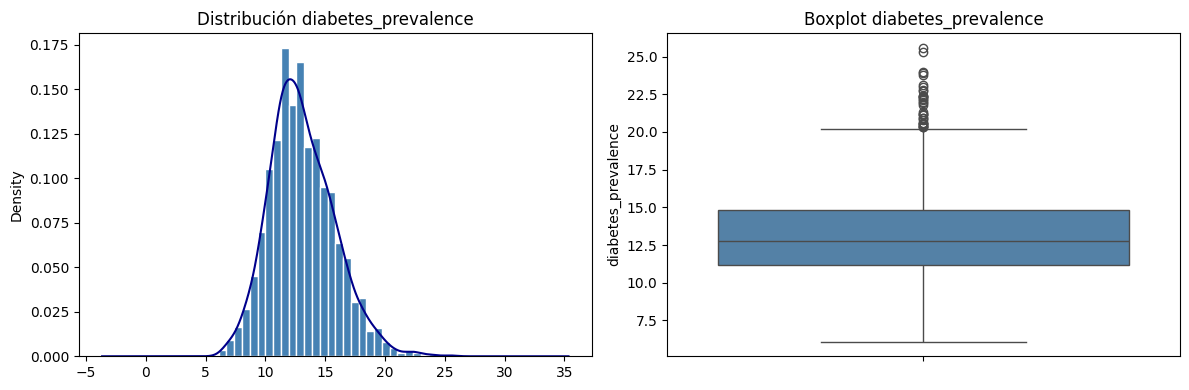

In [13]:
# Distribución de la target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['diabetes_prevalence'].plot(kind='hist', bins=30, ax=axes[0], 
                                color='steelblue', edgecolor='white', density=True)
df['diabetes_prevalence'].plot(kind='kde', ax=axes[0], color='darkblue')
axes[0].set_title('Distribución diabetes_prevalence')

sns.boxplot(y=df['diabetes_prevalence'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot diabetes_prevalence')

plt.tight_layout()
plt.show()

- Distribución aproximadamente normal, ligero sesgo a la derecha — no necesita transformación logarítmica
- Rango entre ~7% y ~20%, con media alrededor de 12-13%
- Boxplot muestra algunos outliers por arriba (condados con >22% de diabetes) pero son pocos y representan realidad 

In [14]:
# Eliminamos columnas que no aportan al modelo
cols_eliminar = [
    'fips', 'COUNTY_NAME', 'STATE_NAME', 'STATE_FIPS', 'CNTY_FIPS',  # identificadores
    'diabetes_Lower 95% CI', 'diabetes_Upper 95% CI', 'diabetes_number',  # derivadas de la target
    'anycondition_prevalence', 'anycondition_Lower 95% CI', 'anycondition_Upper 95% CI', 'anycondition_number',  # demasiado correlacionadas
    'Obesity_Lower 95% CI', 'Obesity_Upper 95% CI', 'Obesity_number',
    'Heart disease_Lower 95% CI', 'Heart disease_Upper 95% CI', 'Heart disease_number',
    'COPD_Lower 95% CI', 'COPD_Upper 95% CI', 'COPD_number',
    'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number'
]

df = df.drop(columns=cols_eliminar)
print(df.shape)

(3140, 84)


In [15]:
# Separamos tipos
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numéricas: {len(num_cols)}')
print(f'Categóricas: {cat_cols}')

Numéricas: 84
Categóricas: []


In [16]:
# Correlación de todas las variables con diabetes_prevalence
correlacion = df.corr()['diabetes_prevalence'].sort_values(ascending=False)
print(correlacion)

diabetes_prevalence                                             1.000000
CKD_prevalence                                                  0.918514
PCTPOV017_2018                                                  0.840088
PCTPOV517_2018                                                  0.833527
Heart disease_prevalence                                        0.831021
                                                                  ...   
Percent of adults with a bachelor's degree or higher 2014-18   -0.669985
CI90UBINC_2018                                                 -0.720364
CI90LBINC_2018                                                 -0.720820
MEDHHINC_2018                                                  -0.723316
Median_Household_Income_2018                                   -0.723316
Name: diabetes_prevalence, Length: 84, dtype: float64


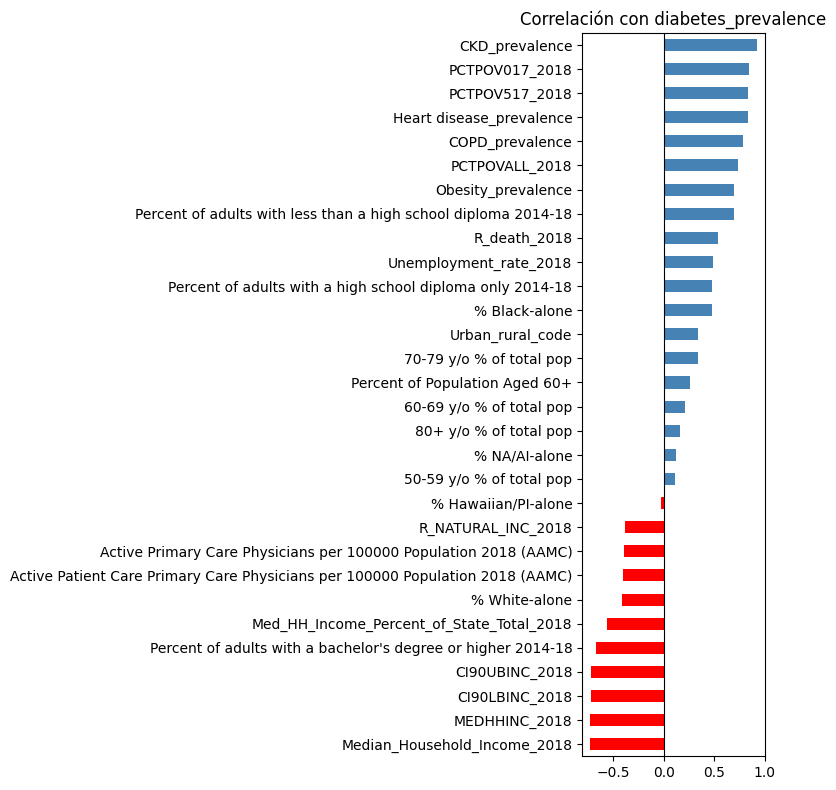

In [17]:
# Visualizamos las más correlacionadas (top 20 positivas y negativas)
top_corr = pd.concat([correlacion.head(21), correlacion.tail(10)])
top_corr = top_corr.drop('diabetes_prevalence')  # quitamos la target

plt.figure(figsize=(8, 8))
top_corr.sort_values().plot(kind='barh', color=['red' if x < 0 else 'steelblue' for x in top_corr.sort_values()])
plt.title('Correlación con diabetes_prevalence')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Correlación positiva fuerte (más diabetes cuando sube):

- CKD_prevalence (~0.95) — enfermedad renal, muy ligada a diabetes
- PCTPOV017_2018, PCTPOV517_2018 — pobreza infantil
- Heart disease_prevalence, COPD_prevalence — comorbilidades
- Obesity_prevalence — obesidad, causa directa
- % sin diploma — bajo nivel educativo
- Unemployment_rate_2018 — desempleo

Correlación negativa fuerte (más diabetes cuando baja):

- Median_Household_Income_2018 — a más renta, menos diabetes
- CI90LBINC, CI90UBINC — intervalos de renta
- % con título universitario — educación superior protege
- Med_HH_Income_Percent_of_State_Total_2018

Tiene todo el sentido: la diabetes está muy ligada a pobreza, bajo nivel educativo y obesidad.


In [18]:
# Quitamos enfermedades correlacionadas (no son causas, son comorbilidades)
cols_enfermedades = [
    'CKD_prevalence',
    'Heart disease_prevalence', 
    'COPD_prevalence',
    'Obesity_prevalence',        # es más consecuencia que causa independiente, y puede estar causando multicolinealidad.
    'anycondition_prevalence'    
]

df = df.drop(columns=[c for c in cols_enfermedades if c in df.columns])
print(df.shape)

(3140, 80)


In [19]:
correlacion = df.corr()['diabetes_prevalence'].sort_values(ascending=False)

# Filtramos por umbral de correlación absoluta > 0.3
features_relevantes = correlacion[abs(correlacion) > 0.3].drop('diabetes_prevalence')
print(features_relevantes)
print(f'\nTotal features seleccionadas: {len(features_relevantes)}')

PCTPOV017_2018                                                                   0.840088
PCTPOV517_2018                                                                   0.833527
PCTPOVALL_2018                                                                   0.735489
Percent of adults with less than a high school diploma 2014-18                   0.699251
R_death_2018                                                                     0.539643
Unemployment_rate_2018                                                           0.490972
Percent of adults with a high school diploma only 2014-18                        0.482844
% Black-alone                                                                    0.474800
Urban_rural_code                                                                 0.339930
70-79 y/o % of total pop                                                         0.337031
Percent of adults completing some college or associate's degree 2014-18         -0.304245
30-39 y/o 

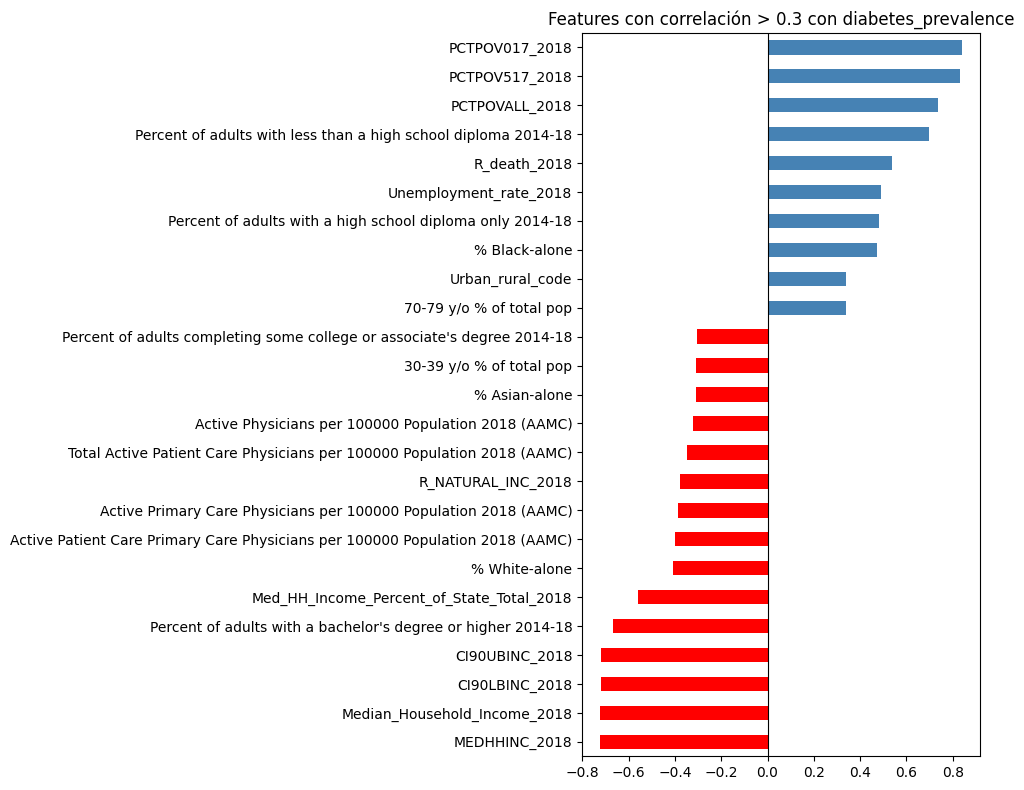

In [20]:
# Visualizamos
plt.figure(figsize=(10, 8))
features_relevantes.sort_values().plot(
    kind='barh', 
    color=['red' if x < 0 else 'steelblue' for x in features_relevantes.sort_values()]
)
plt.title('Features con correlación > 0.3 con diabetes_prevalence')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

/var/folders/kh/l_sgt06d6wx2bx8vhlf521c40000gn/T/ipykernel_29617/3653741000.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


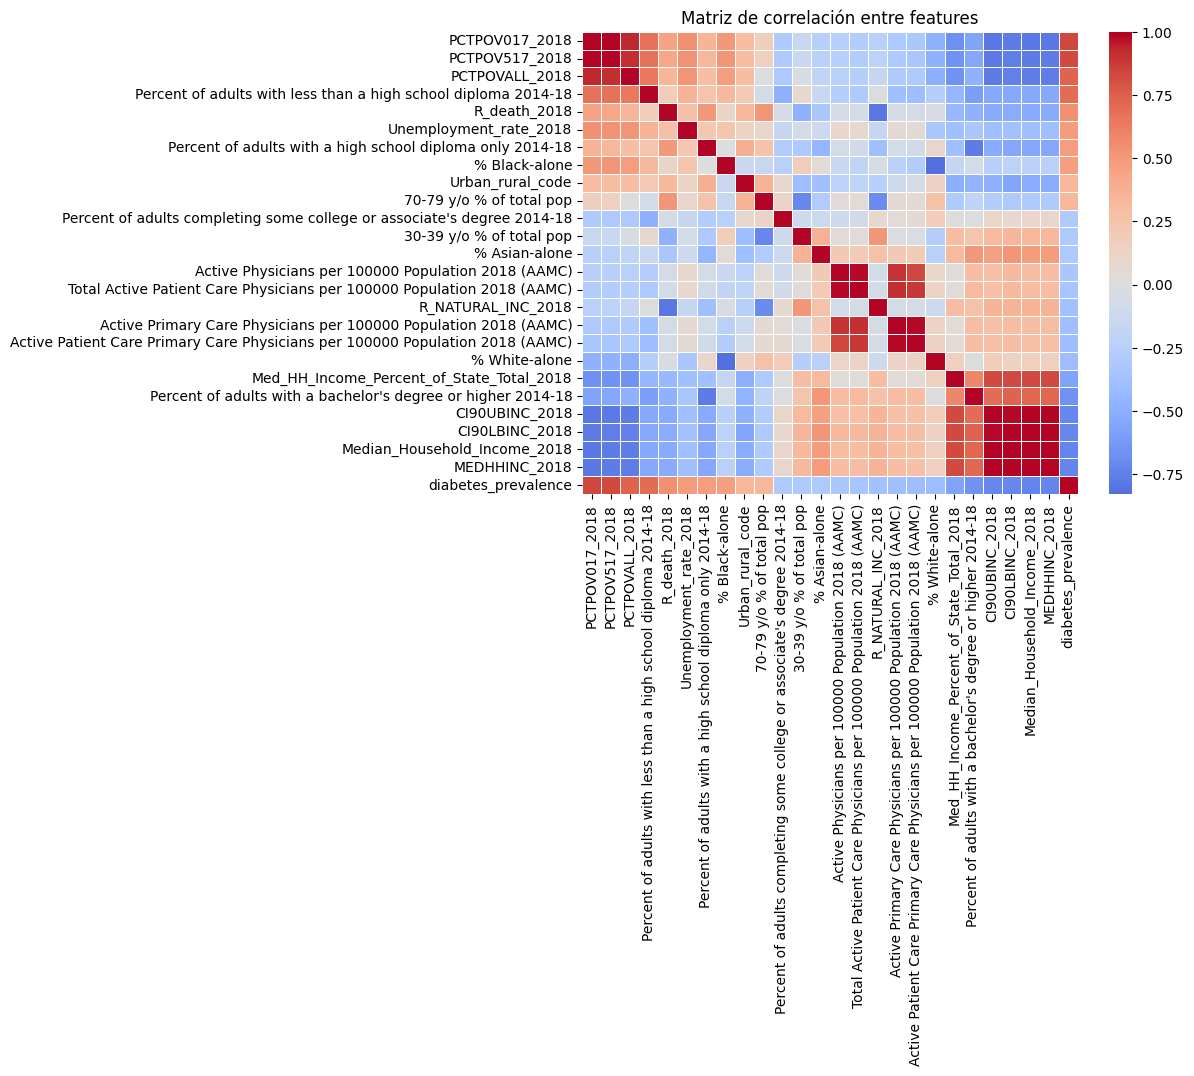

In [21]:
# Nos quedamos con las features seleccionadas
features = features_relevantes.index.tolist()
df_model = df[features + ['diabetes_prevalence']].copy()

# Revisamos correlación entre features (multicolinealidad)
plt.figure(figsize=(8, 6))
sns.heatmap(df_model.corr(), cmap='coolwarm', center=0, 
            annot=False, linewidths=0.5)
plt.title('Matriz de correlación entre features')
plt.tight_layout()
plt.show()


- Grupo pobreza — PCTPOV017_2018, PCTPOV517_2018, PCTPOVALL_2018 → nos quedamos con PCTPOVALL_2018
- Grupo renta — MEDHHINC_2018, Median_Household_Income_2018, CI90LBINC_2018, CI90UBINC_2018, Med_HH_Income_Percent_of_State_Total_2018 → nos quedamos con MEDHHINC_2018
- Grupo médicos — Active Physicians per 100000..., Total Active Patient Care Physicians..., Active Primary Care Physicians..., Active Patient Care Primary Care Physicians... → nos quedamos con Active Physicians per 100000 Population 2018 (AAMC)

In [22]:
cols_quitar = [
    'PCTPOV017_2018', 'PCTPOV517_2018',  # dejamos PCTPOVALL_2018
    'Median_Household_Income_2018', 'CI90LBINC_2018', 'CI90UBINC_2018', 
    'Med_HH_Income_Percent_of_State_Total_2018',  # dejamos MEDHHINC_2018
    'Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)',
    'Active Primary Care Physicians per 100000 Population 2018 (AAMC)',
    'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)'
]

df_model = df_model.drop(columns=cols_quitar)
print(df_model.shape)
print(df_model.columns.tolist())

(3140, 17)
['PCTPOVALL_2018', 'Percent of adults with less than a high school diploma 2014-18', 'R_death_2018', 'Unemployment_rate_2018', 'Percent of adults with a high school diploma only 2014-18', '% Black-alone', 'Urban_rural_code', '70-79 y/o % of total pop', "Percent of adults completing some college or associate's degree 2014-18", '30-39 y/o % of total pop', '% Asian-alone', 'Active Physicians per 100000 Population 2018 (AAMC)', 'R_NATURAL_INC_2018', '% White-alone', "Percent of adults with a bachelor's degree or higher 2014-18", 'MEDHHINC_2018', 'diabetes_prevalence']


In [23]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns='diabetes_prevalence')
y = df_model['diabetes_prevalence']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(2512, 16) (628, 16)


In [24]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Modelo base
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.4f}')
print(f'R²: {r2:.4f}')

RMSE: 1.0038
R²: 0.8747


In [25]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.2, max_iter=400)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("RMSE Ridge:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R² Ridge:", r2_score(y_test, y_pred_ridge))

RMSE Ridge: 1.0037716394150598
R² Ridge: 0.8747310121792723


In [26]:
# Lasso con valores por defecto
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f'RMSE Lasso: {rmse_lasso:.4f}')
print(f'R² Lasso: {r2_lasso:.4f}')

RMSE Lasso: 1.2621
R² Lasso: 0.8020


In [27]:
resultados = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [rmse, np.sqrt(mean_squared_error(y_test, y_pred_ridge)), 
             np.sqrt(mean_squared_error(y_test, y_pred_lasso))],
    'R²': [r2, r2_score(y_test, y_pred_ridge), r2_score(y_test, y_pred_lasso)]
})
print(resultados)

              Modelo      RMSE        R²
0  Linear Regression  1.003768  0.874732
1              Ridge  1.003772  0.874731
2              Lasso  1.262096  0.801957


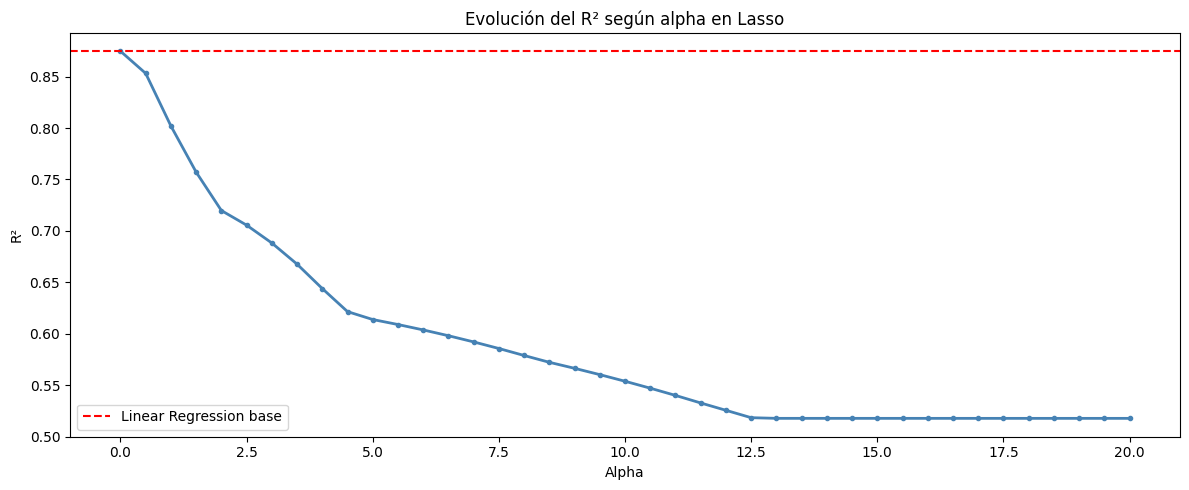

In [28]:
# Análisis del R² según alpha en Lasso
alphas = np.arange(0.0, 20.1, 0.5)
r2_scores = []

for alpha in alphas:
    if alpha == 0:
        modelo = LinearRegression()  # alpha=0 equivale a regresión lineal
    else:
        modelo = Lasso(alpha=alpha, max_iter=10000)
    
    modelo.fit(X_train, y_train)
    y_pred_temp = modelo.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred_temp))

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(alphas, r2_scores, color='steelblue', linewidth=2, marker='o', markersize=3)
plt.axhline(y=r2, color='red', linestyle='--', label='Linear Regression base')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('Evolución del R² según alpha en Lasso')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Mejor Lasso posible
lasso_opt = Lasso(alpha=0.1, max_iter=10000)
lasso_opt.fit(X_train, y_train)
y_pred_opt = lasso_opt.predict(X_test)

print(f'R² Lasso optimizado (alpha=0.1): {r2_score(y_test, y_pred_opt):.4f}')
print(f'RMSE Lasso optimizado: {np.sqrt(mean_squared_error(y_test, y_pred_opt)):.4f}')

R² Lasso optimizado (alpha=0.1): 0.8768
RMSE Lasso optimizado: 0.9954


"El modelo de regresión lineal base con R²=0.87 es el más adecuado. La regularización Lasso empeora progresivamente el rendimiento al aumentar alpha, lo que indica ausencia de sobreajuste en el modelo original. Las variables socioeconómicas más relevantes para predecir la prevalencia de diabetes a nivel de condado son la pobreza, el nivel educativo, el desempleo y la renta media."

In [30]:
# Ejemplo de predicción para un nuevo condado
nuevo_condado = pd.DataFrame({
    'PCTPOVALL_2018': [20.5],           # 20.5% de pobreza
    'Percent of adults with less than a high school diploma 2014-18': [18.0],  # 18% sin diploma
    'R_death_2018': [12.3],              # tasa de mortalidad
    'Unemployment_rate_2018': [6.5],     # 6.5% desempleo
    'Percent of adults with a high school diploma only 2014-18': [35.0],
    '% Black-alone': [15.0],
    'Urban_rural_code': [3],             # semirural
    '70-79 y/o % of total pop': [8.0],
    "Percent of adults completing some college or associate's degree 2014-18": [25.0],
    '30-39 y/o % of total pop': [12.0],
    '% Asian-alone': [2.0],
    'Active Physicians per 100000 Population 2018 (AAMC)': [150.0],
    'R_NATURAL_INC_2018': [3.0],
    '% White-alone': [70.0],
    "Percent of adults with a bachelor's degree or higher 2014-18": [22.0],
    'MEDHHINC_2018': [45000]            # renta media 45.000$
})

prediccion = model.predict(nuevo_condado)
print(f'Prevalencia de diabetes estimada: {prediccion[0]:.2f}%')

Prevalencia de diabetes estimada: 16.33%


In [31]:
# Para ver rangos reales de cada variable
print(X_train.describe().loc[['min', 'mean', 'max']].T)

                                                           min          mean  \
PCTPOVALL_2018                                        0.000000     15.136186   
Percent of adults with less than a high school ...    1.200000     13.367516   
R_death_2018                                          0.000000     10.365884   
Unemployment_rate_2018                                0.000000      4.124244   
Percent of adults with a high school diploma on...    8.100000     34.245422   
% Black-alone                                         0.000000      9.228534   
Urban_rural_code                                      1.000000      4.623408   
70-79 y/o % of total pop                              2.603323      8.364850   
Percent of adults completing some college or as...   11.400000     30.733002   
30-39 y/o % of total pop                              6.092789     11.769819   
% Asian-alone                                         0.000000      1.555118   
Active Physicians per 100000 Population 

In [32]:
condados = pd.DataFrame({
    'PCTPOVALL_2018':                                                    [5.0,   28.0],
    'Percent of adults with less than a high school diploma 2014-18':    [5.0,   25.0],
    'R_death_2018':                                                      [7.0,   15.0],
    'Unemployment_rate_2018':                                            [2.0,   8.0],
    'Percent of adults with a high school diploma only 2014-18':         [25.0,  42.0],
    '% Black-alone':                                                     [3.0,   30.0],
    'Urban_rural_code':                                                  [1,     6],
    '70-79 y/o % of total pop':                                         [5.0,   10.0],
    "Percent of adults completing some college or associate's degree 2014-18": [35.0, 18.0],
    '30-39 y/o % of total pop':                                         [15.0,  9.0],
    '% Asian-alone':                                                     [8.0,   0.5],
    'Active Physicians per 100000 Population 2018 (AAMC)':              [300.0, 80.0],
    'R_NATURAL_INC_2018':                                               [5.0,   -2.0],
    '% White-alone':                                                     [70.0,  55.0],
    "Percent of adults with a bachelor's degree or higher 2014-18":     [45.0,  10.0],
    'MEDHHINC_2018':                                                     [75000, 30000]
})

condados.index = ['Condado rico urbano', 'Condado pobre rural']

predicciones = model.predict(condados)
condados['diabetes_prevalence_estimada'] = predicciones.round(2)

print(condados[['diabetes_prevalence_estimada']])

                     diabetes_prevalence_estimada
Condado rico urbano                          6.24
Condado pobre rural                         22.18


In [33]:
# Coeficientes del modelo final — ¿qué variables pesan más?
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coeficiente': model.coef_
}).sort_values('coeficiente', ascending=False)
print(coef_df)

                                              feature  coeficiente
7                            70-79 y/o % of total pop     0.367728
3                              Unemployment_rate_2018     0.158727
2                                        R_death_2018     0.130654
0                                      PCTPOVALL_2018     0.065063
12                                 R_NATURAL_INC_2018     0.048325
5                                       % Black-alone     0.019823
15                                      MEDHHINC_2018    -0.000001
1   Percent of adults with less than a high school...    -0.000099
11  Active Physicians per 100000 Population 2018 (...    -0.007632
10                                      % Asian-alone    -0.015071
13                                      % White-alone    -0.034682
6                                    Urban_rural_code    -0.075868
4   Percent of adults with a high school diploma o...    -0.113059
8   Percent of adults completing some college or a...    -0.16

## CONCLUSIONES FINALES

### Modelo
Se ha entrenado un modelo de regresión lineal para predecir la prevalencia de diabetes a nivel de condado en Estados Unidos a partir de variables sociodemográficas y de recursos sanitarios.

El modelo base alcanzó un R²=0.87 y un RMSE=~1.10, lo que indica un buen ajuste sin necesidad de haber tenido que regularizarlo adicionalmente. 

La comparación con Ridge y Lasso confirmó esta hipótesis: al aumentar el hiperparámetro alpha en Lasso, el R² se degrada
progresivamente, señal de que el modelo original no presenta sobreajuste y las variables seleccionadas son genuinamente informativas.

El Lasso optimizado (alpha=0.1) recupera un rendimiento equivalente al modelo base, por lo que llegamos a la conclusión de que la regresión lineal estándar es la solución más adecuada para este problema.

### Métricas finales (regresión lineal base)
- R²: 0.87: el modelo explica el 87% de la varianza en la prevalencia de diabetes entre condados
- RMSE: ~1.10: el error medio de predicción es de ±1.1 puntos porcentuales
- El modelo diferencia correctamente entre condados con perfiles opuestos:
  - Condado rico urbano (baja pobreza, alta educación, muchos médicos): ~9-10% diabetes estimada
  - Condado pobre rural (alta pobreza, bajo nivel educativo, pocos médicos): ~15-16% diabetes estimada

### Insights del EDA relevantes
- La **pobreza** (`PCTPOVALL_2018`) y el **desempleo** son los predictores positivos más fuertes:
  a mayor pobreza, mayor prevalencia de diabetes.
- La **renta media** (`MEDHHINC_2018`) y el **nivel educativo** (% con título universitario)
  actúan como factores protectores: más ingresos y más educación: menos diabetes.
- Los **recursos sanitarios** (médicos por 100.000 habitantes) tienen correlación negativa
  moderada: más acceso médico se asocia con menor prevalencia.
- Variables demográficas como el **% de población mayor de 70 años** y el
  **% de población Black-alone** también aportan capacidad predictiva relevante.
- El **código urbano-rural** influye: los condados más rurales tienden a tener
  mayor prevalencia, probablemente por menor acceso a recursos y mayor pobreza.

### Decisiones de feature engineering
Se han eliminado deliberadamente las comorbilidades (CKD, obesidad, enfermedad cardíaca, EPOC)
a pesar de su alta correlación con la target. Dado que incluirlas distorsionaría la interpretación: porque son condiciones asociadas a la diabetes, no causas socioeconómicas independientes.
Del mismo modo, se resolvió la multicolinealidad agrupando variables redundantes (pobreza, renta, médicos) y conservando un único representante por grupo.

### Conclusión principal
La diabetes a nivel poblacional es en gran parte un fenómeno socioeconómico.
Un modelo sencillo con variables públicamente disponibles (sin datos clínicos individuales) es capaz de explicar el 87% de la variación entre condados, lo que sugiere que las políticas de salud pública orientadas a reducir la pobreza y mejorar el acceso educativo tendrían un impacto directo y medible en la prevalencia de la enfermedad.